# Gemstome Price Prediction

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


### Introduction About the Data :

**The dataset** The goal is to predict `price` of given diamond (Regression Analysis).

There are 10 independent variables (including `id`):

* `id` : unique identifier of each diamond
* `carat` : Carat (ct.) refers to the unique unit of weight measurement used exclusively to weigh gemstones and diamonds.
* `cut` : Quality of Diamond Cut
* `color` : Color of Diamond
* `clarity` : Diamond clarity is a measure of the purity and rarity of the stone, graded by the visibility of these characteristics under 10-power magnification.
* `depth` : The depth of diamond is its height (in millimeters) measured from the culet (bottom tip) to the table (flat, top surface)
* `table` : A diamond's table is the facet which can be seen when the stone is viewed face up.
* `x` : Diamond X dimension
* `y` : Diamond Y dimension
* `x` : Diamond Z dimension

Target variable:
* `price`: Price of the given Diamond.

Dataset Source Link :
[https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv](https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv)

In [4]:
df.shape


(193573, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


id column is dropped as it is insignificant

In [4]:
df=df.drop(['id'], axis=1)

In [5]:
#checking missing value
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [8]:
#checking dupplicate value
df.duplicated().sum()

np.int64(0)

In [9]:
num_col=list(df.columns[df.dtypes!='object'])
print("Numrical_col: " ,num_col)
cat_col=list(df.columns[df.dtypes=='object'])
print(f'Categorical column : {cat_col}')


Numrical_col:  ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
Categorical column : ['cut', 'color', 'clarity']


numerical column description

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,193573.0,0.790688,0.462688,0.2,0.40,0.70,1.03,3.50
depth,193573.0,61.820574,1.081704,52.1,61.30,61.90,62.40,71.60
table,193573.0,57.227675,1.918844,49.0,56.00,57.00,58.00,79.00
x,193573.0,5.715312,1.109422,0.0,4.70,5.70,6.51,9.65
y,193573.0,5.720094,1.102333,0.0,4.71,5.72,6.51,10.01
z,193573.0,3.534246,0.688922,0.0,2.90,3.53,4.03,31.30
price,193573.0,3969.155414,4034.374138,326.0,951.00,2401.00,5408.00,18818.00


categorical column description

In [11]:
df[cat_col].describe().T


,count,unique,top,freq
cut,193573,5,Ideal,92454
color,193573,7,G,44391
clarity,193573,8,SI1,53272


In [6]:
df.nunique()

carat       248
cut           5
color         7
clarity       8
depth       153
table       108
x           522
y           521
z           349
price      8738
dtype: int64

### Univariate Analysis of Numerical Variables

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
import plotly.express as px
counts= df['carat'].value_counts().sort_index()



# for col in num_col:
fig = px.bar(
        x=counts.index,
        y=counts.values
        # nbins=30,
        # color_discrete_sequence=['darkgreen'],
   
        # opacity=0.8
    )
fig.update_layout(bargap=0.2)
    # fig.update_layout(
    #     title=f"Distribution of {col}",
    #     xaxis_title=col,
    #     yaxis_title="Frequency",
    #     # template="plotly_dark",  # or "plotly_white"
    #     width=700,
    #     height=400
    # )
fig.show()


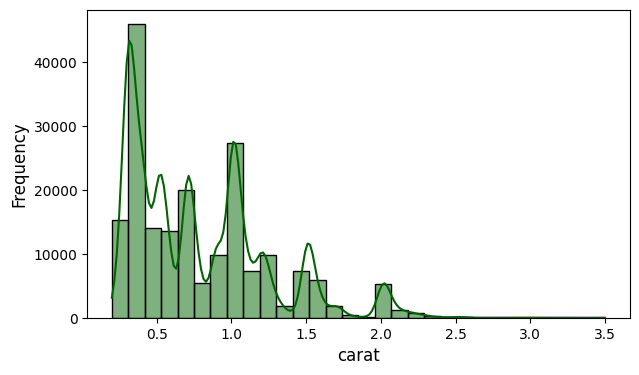

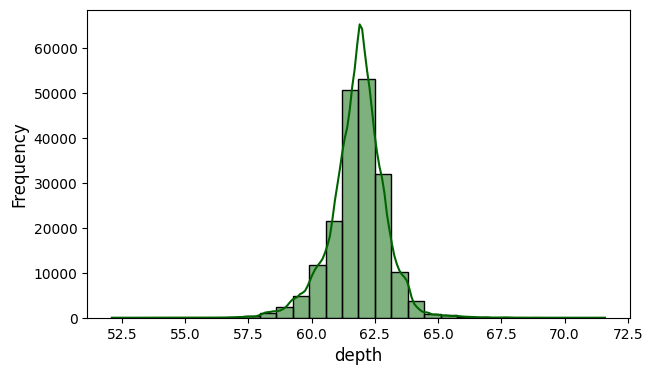

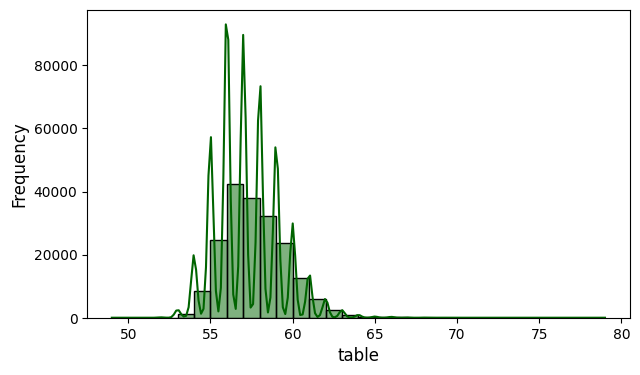

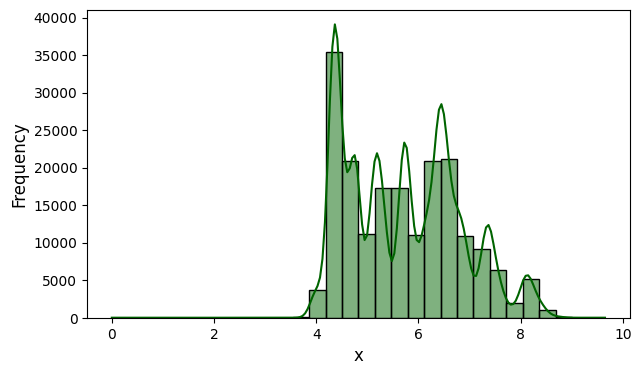

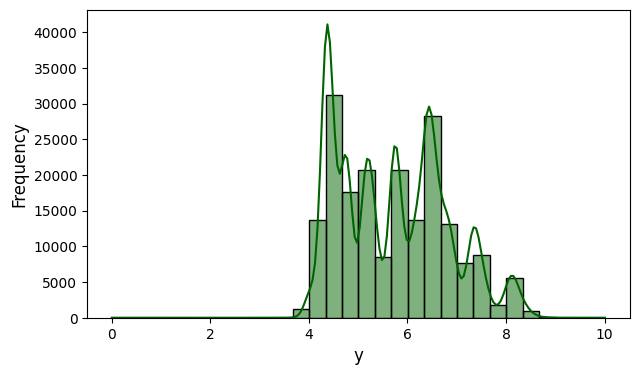

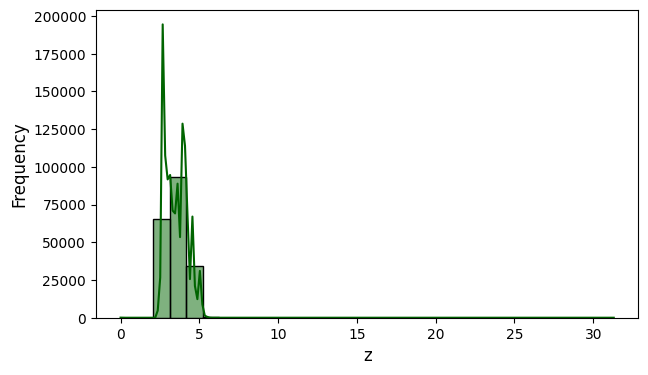

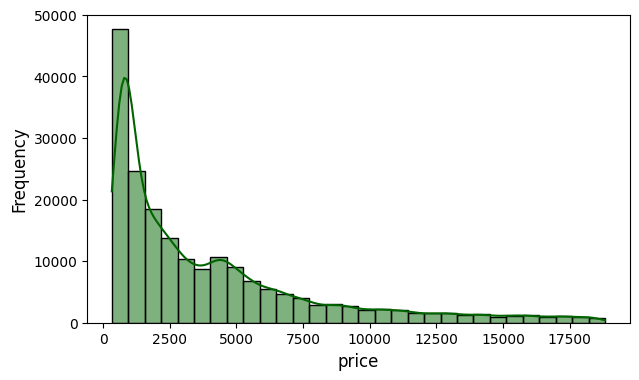

In [10]:
# import plotly.figure_factory as ff
# import numpy as np

# # Loop through all numerical columns
# for col in num_col:
#     # Drop missing values to avoid errors
#     col_data = df[col].dropna()

#     # Create distplot (histogram + KDE)
#     fig = ff.create_distplot(
#         [col_data],
#         group_labels=[col],
#         colors=["darkgreen"],
#         show_hist=True,
#         show_rug=False,
#         bin_size=0.2  # adjust bin width as needed
#     )

#     # Update layout for style and spacing
#     fig.update_layout(
#         title=dict(
#             text=f"Distribution of {col} with KDE Curve",
#             x=0.5,
#             xanchor="center",
#             font=dict(size=18, family="Arial", color="white")
#         ),
#         xaxis=dict(title=col, showgrid=False, zeroline=False),
#         yaxis=dict(title="Density", showgrid=False, zeroline=False),
#         bargap=0.15,  # ✅ Adds bar gap
#         template="plotly_dark",
#         width=750,
#         height=450
#     )

#     # Add bar border for clarity
#     fig.update_traces(marker_line_width=1, marker_line_color="black")

#     fig.show()
for col in num_col:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col],kde=True,color='darkgreen', bins=30)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()

![alt text](image.png)

### Univariate analysis for categorical variables

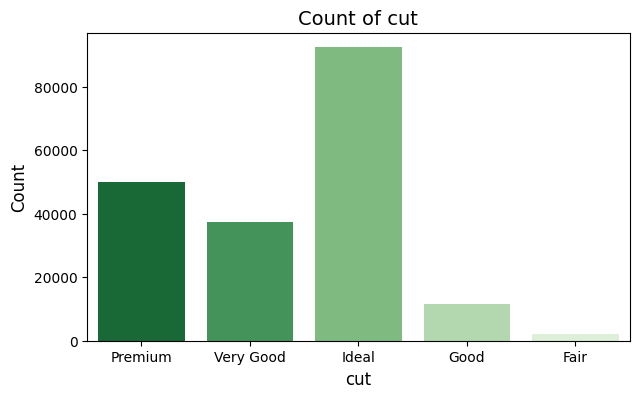

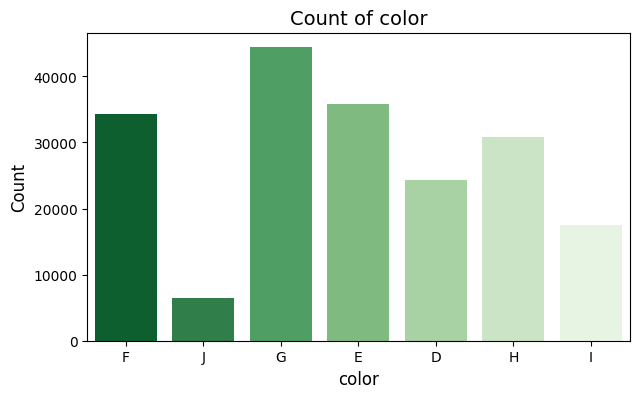

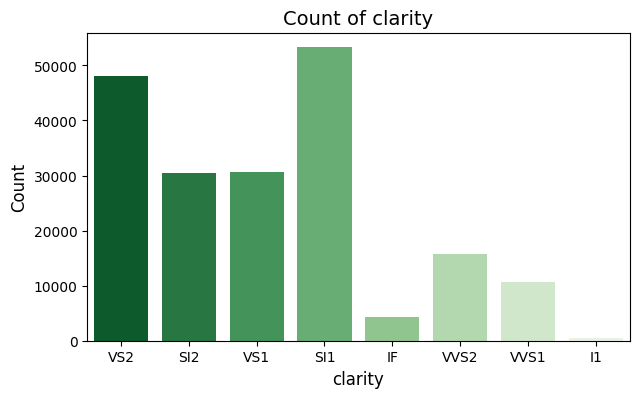

In [15]:
for col in cat_col:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue=col, palette='Greens_r', legend=False)
    plt.title(f'Count of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()
    print('\n')

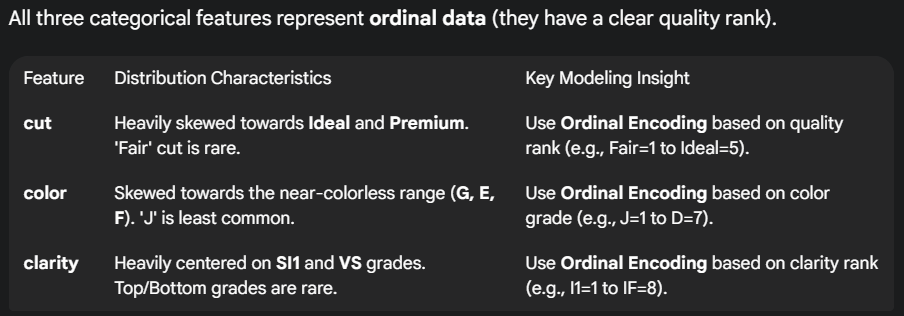

## Bivariate Analysis

<Axes: >

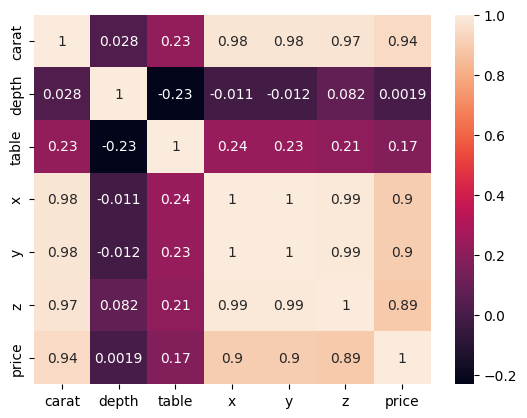

In [16]:
sns.heatmap(df[num_col].corr(),annot=True)

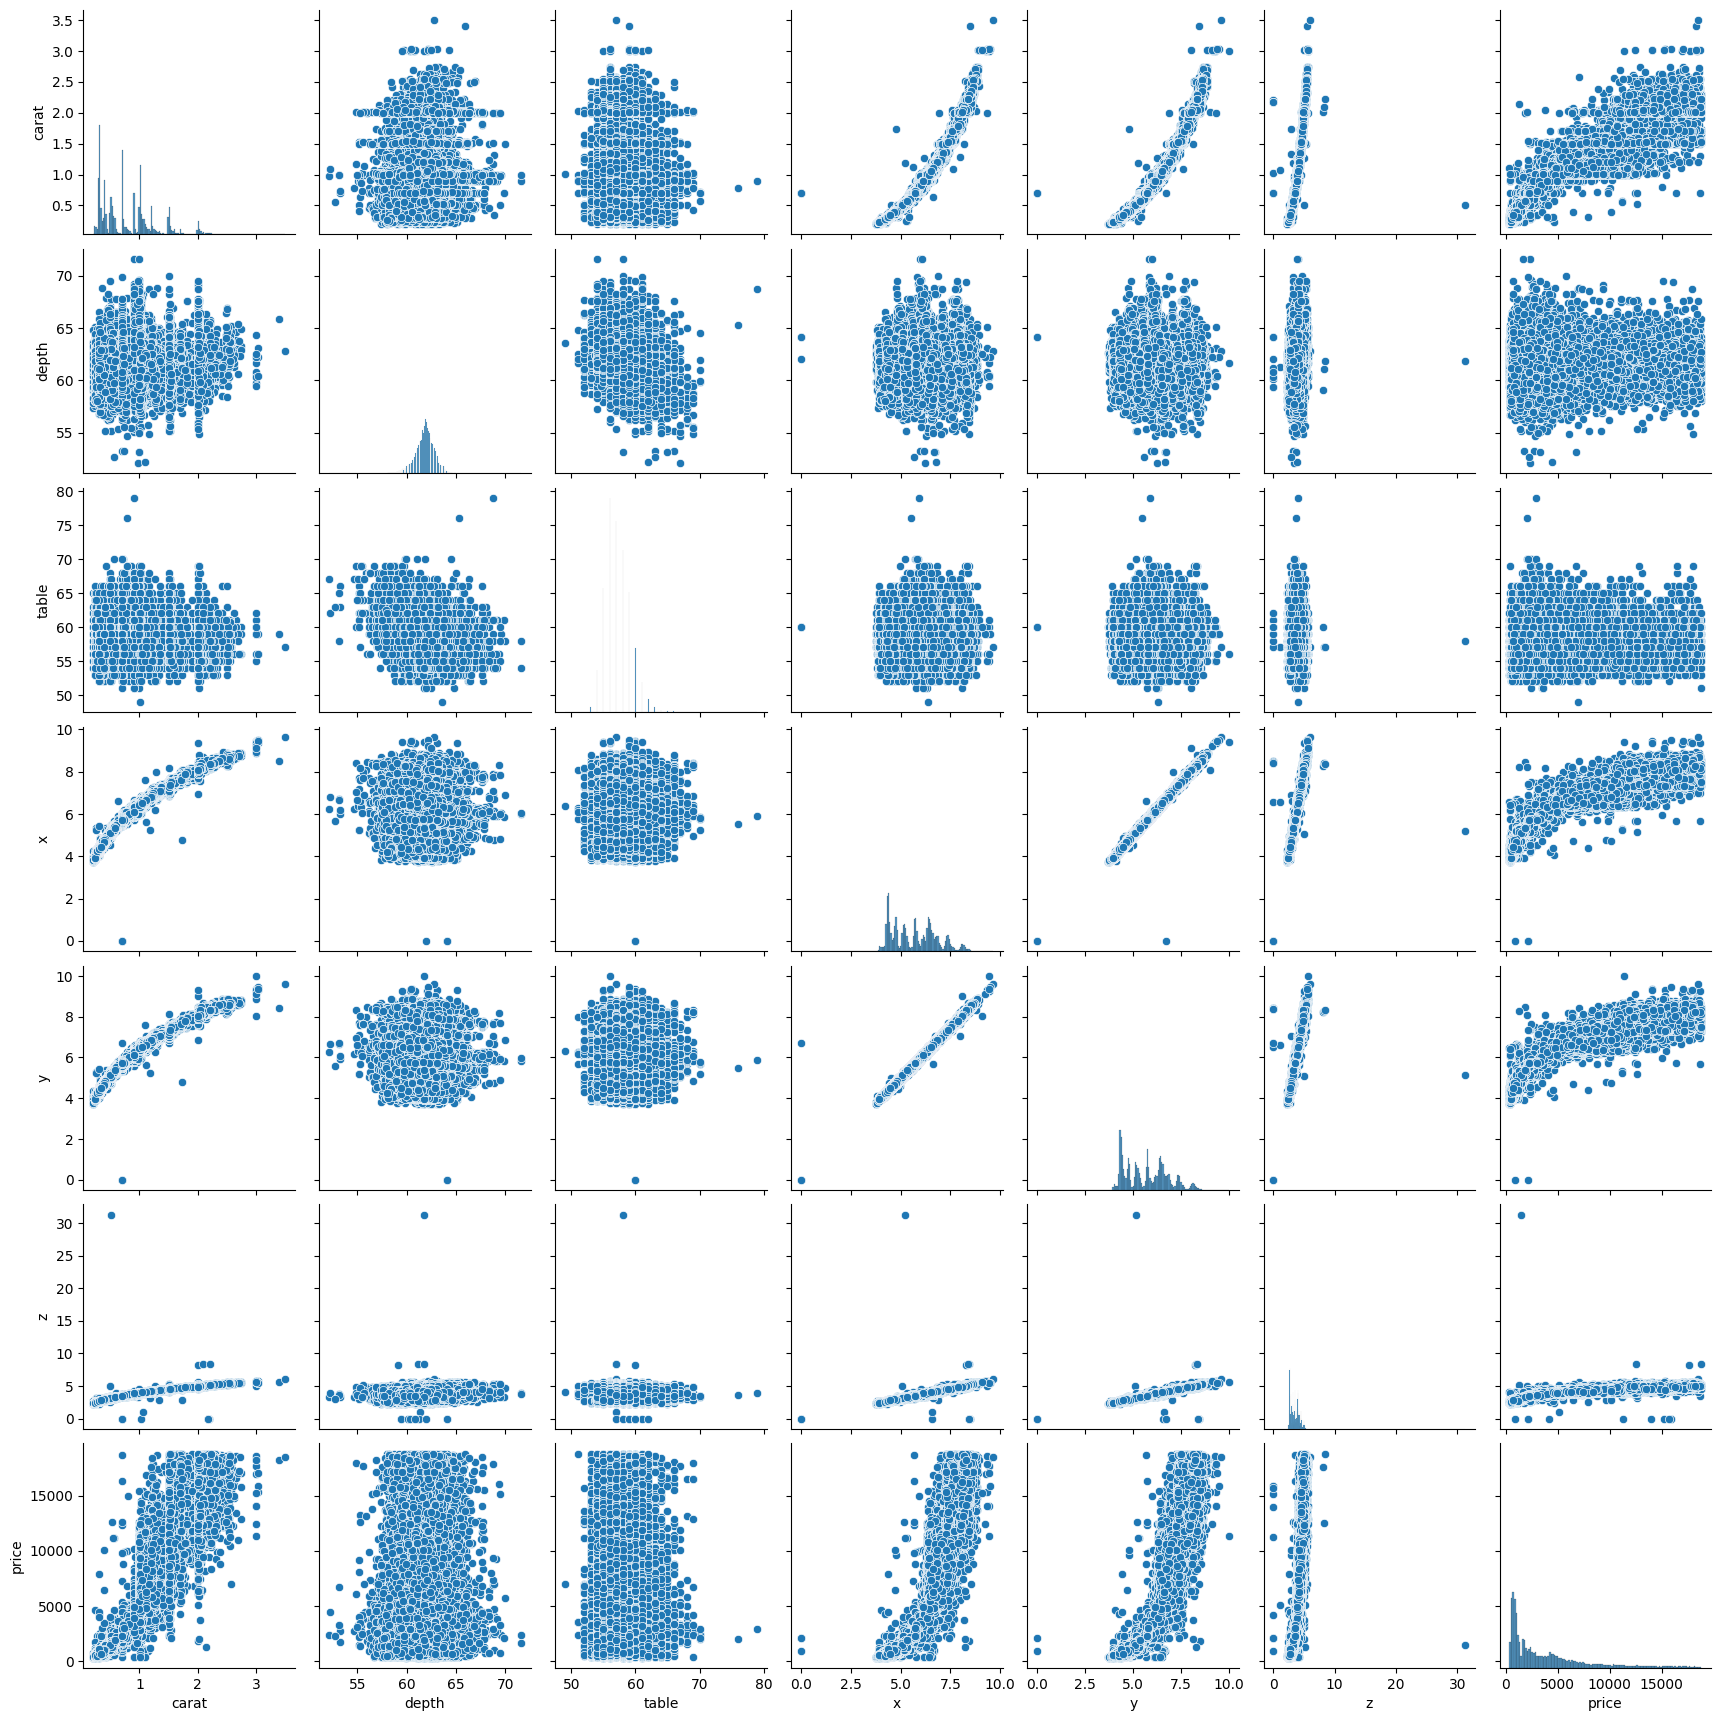

In [17]:
sns.pairplot(df)

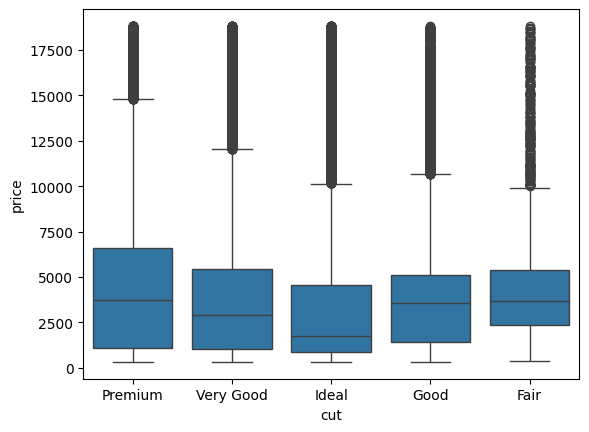

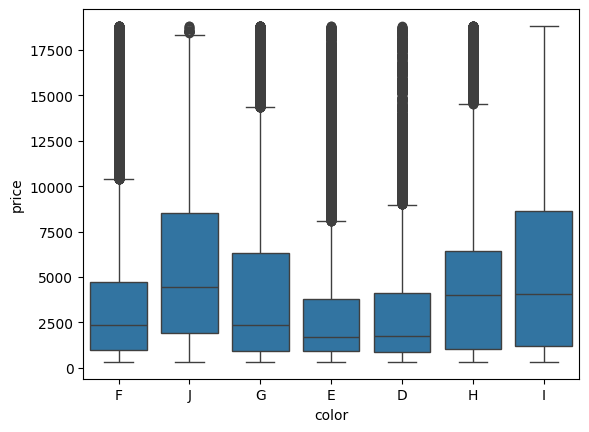

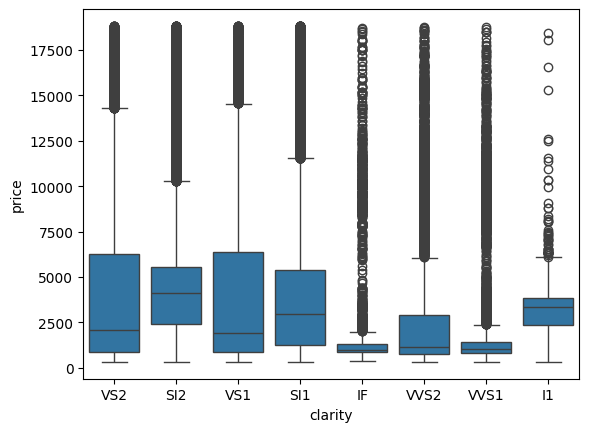

In [18]:
for i in cat_col:
    sns.boxplot(data=df, x=i , y='price')
    plt.show()

## Ordinal mapping of Categorical Value

In [19]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='object')

In [20]:
print(df['cut'].unique())
print(df['color'].unique())
print(df['clarity'].unique())


['Premium' 'Very Good' 'Ideal' 'Good' 'Fair']
['F' 'J' 'G' 'E' 'D' 'H' 'I']
['VS2' 'SI2' 'VS1' 'SI1' 'IF' 'VVS2' 'VVS1' 'I1']


In [21]:
# Define mapping dictionaries
cut_mapper = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5}
color_mapper = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}   #In the diamond industry, D is the best (most colorless) grade, and J is the worst (most yellowish/tinted) grade in this set.
clarity_mapper = {"I1": 1, "SI2": 2, "SI1": 3, "VS2": 4, "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8}

# Apply mapping using .map()
df['cut'] = df['cut'].map(cut_mapper)
df['color'] = df['color'].map(color_mapper)
df['clarity'] = df['clarity'].map(clarity_mapper)


In [22]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,4,5,4,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,3,1,2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71,666
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77,14453


In [23]:
print(df[['cut', 'color', 'clarity']].isna().sum())


cut        0
color      0
clarity    0
dtype: int64


In [24]:
from sklearn.feature_selection import mutual_info_regression

In [25]:
x=df.drop(['price'],axis=1)
y=df['price']

In [26]:
print(x)

        carat  cut  color  clarity  depth  table     x     y     z
0        1.52    4      5        4   62.2   58.0  7.27  7.33  4.55
1        2.03    3      1        2   62.0   58.0  8.06  8.12  5.05
2        0.70    5      4        5   61.2   57.0  5.69  5.73  3.50
3        0.32    5      4        5   61.6   56.0  4.38  4.41  2.71
4        1.70    4      4        4   62.6   59.0  7.65  7.61  4.77
...       ...  ...    ...      ...    ...    ...   ...   ...   ...
193568   0.31    5      7        6   61.1   56.0  4.35  4.39  2.67
193569   0.70    4      4        6   60.3   58.0  5.75  5.77  3.47
193570   0.73    3      5        3   63.1   57.0  5.72  5.75  3.62
193571   0.34    3      7        3   62.9   55.0  4.45  4.49  2.81
193572   0.71    2      6        2   60.8   64.0  5.73  5.71  3.48

[193573 rows x 9 columns]


In [27]:
print(y)

0         13619
1         13387
2          2772
3           666
4         14453
          ...  
193568     1130
193569     2874
193570     3036
193571      681
193572     2258
Name: price, Length: 193573, dtype: int64


In [28]:
mi_scores=mutual_info_regression(x,y)
mi_scores = pd.Series(mi_scores, index=x.columns).sort_values(ascending=False)

In [29]:
print(mi_scores)

carat      1.824669
x          1.672482
y          1.665639
z          1.616670
clarity    0.399036
color      0.285898
table      0.112115
cut        0.093191
depth      0.045899
dtype: float64


C:\Users\ASHISH RAJ\AppData\Local\Temp\ipykernel_17076\248881159.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




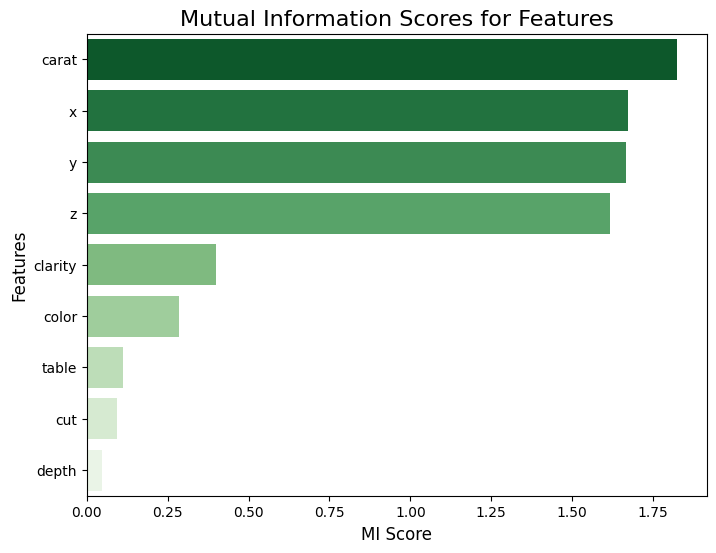

In [30]:
plt.figure(figsize=(8,6))
sns.barplot(x=mi_scores.values, y=mi_scores.index, palette='Greens_r')
plt.title("Mutual Information Scores for Features", fontsize=16)
plt.xlabel("MI Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

### Conclusion : Above shows that carat and x, y, z are most important features to predict the price of a gemstone

In [31]:
df.to_csv("diamond_cleaned.csv",index=False)